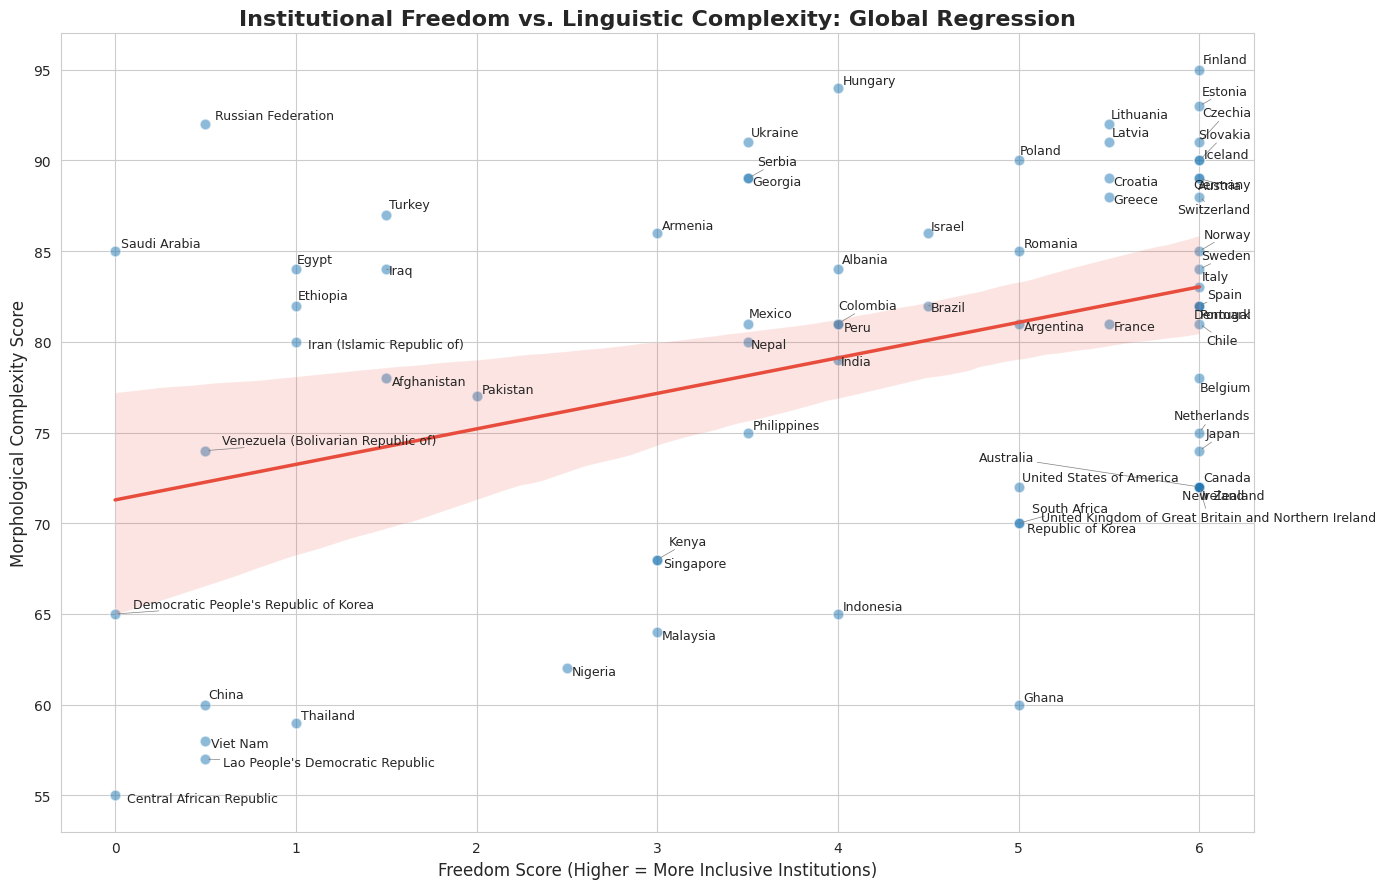

                            OLS Regression Results                            
Dep. Variable:       complexity_score   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     12.14
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           0.000866
Time:                        07:46:00   Log-Likelihood:                -255.94
No. Observations:                  70   AIC:                             515.9
Df Residuals:                      68   BIC:                             520.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            71.2863      2.532     28.155

In [5]:
# 1. INSTALL TOOLS (Added adjust_text)
!pip install country_converter adjustText --upgrade

import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import country_converter as coco
from adjustText import adjust_text  # New import for label cleanup

# 2. FETCH & CLEAN HUMAN FREEDOM INDEX (HFI)
hfi_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2022/2022-02-22/freedom.csv"
try:
    hfi_raw = pd.read_csv(hfi_url)
    hfi_raw.columns = hfi_raw.columns.str.lower()
    cc = coco.CountryConverter()
    hfi_raw['iso'] = cc.convert(names=hfi_raw['country'], to='ISO3')

    # Invert score: Higher = More Free
    hfi_raw['freedom_score'] = 7 - ((hfi_raw['cl'] + hfi_raw['pr']) / 2)
    hfi_df = hfi_raw[hfi_raw['year'] == 2020][['iso', 'country', 'freedom_score']].copy()
except Exception as e:
    print(f"HFI Error: {e}")

# 3. EXPANDED LINGUISTIC COMPLEXITY DATASET
complex_map = {
    'RUS': 92, 'UKR': 91, 'POL': 90, 'FIN': 95, 'HUN': 94, 'EST': 93, 'GRC': 88, 'ISL': 90,
    'DEU': 89, 'AUT': 89, 'CHE': 88, 'TUR': 87, 'ISR': 86, 'SAU': 85, 'EGY': 84, 'IRQ': 84,
    'CZE': 91, 'SVK': 90, 'HRV': 89, 'SRB': 89, 'LTU': 92, 'LVA': 91, 'FRA': 81, 'ESP': 82,
    'ITA': 83, 'PRT': 82, 'ROU': 85, 'NOR': 85, 'SWE': 84, 'DNK': 82, 'ALB': 84, 'ARM': 86,
    'GEO': 89, 'IRN': 80, 'AFG': 78, 'PAK': 77, 'IND': 79, 'NPL': 80, 'USA': 72, 'GBR': 72,
    'CAN': 72, 'AUS': 72, 'NZL': 72, 'IRL': 72, 'NLD': 75, 'BEL': 78, 'MEX': 81, 'ARG': 81,
    'CHL': 81, 'COL': 81, 'PER': 81, 'BRA': 82, 'PHL': 75, 'ZAF': 70, 'CHN': 60, 'VNM': 58,
    'THA': 59, 'KOR': 70, 'JPN': 74, 'IDN': 65, 'MYS': 64, 'SGP': 68, 'NGA': 62, 'GHA': 60,
    'KEN': 68, 'ETH': 82, 'CAF': 55, 'PRK': 65, 'VEN': 74, 'LAO': 57
}
lang_df = pd.DataFrame(list(complex_map.items()), columns=['iso', 'complexity_score'])

# 4. MERGE & ANALYSIS
if 'hfi_df' in locals():
    merged_df = pd.merge(hfi_df, lang_df, on='iso', how='inner')

    if not merged_df.empty:
        X = sm.add_constant(merged_df['freedom_score'])
        model = sm.OLS(merged_df['complexity_score'], X).fit()

        # 5. ADVANCED VISUALIZATION
        plt.figure(figsize=(14, 9))
        sns.set_style("whitegrid") # Cleaner background

        # Regression plot
        ax = sns.regplot(x='freedom_score', y='complexity_score', data=merged_df,
                         scatter_kws={'s': 60, 'alpha': 0.5, 'edgecolor': 'w'},
                         line_kws={'color': '#e74c3c', 'lw': 2.5})

        # Create a list of text objects to be adjusted
        texts = []
        for i, row in merged_df.iterrows():
            texts.append(plt.text(row['freedom_score'], row['complexity_score'], row['country'], fontsize=9))

        # This function automatically moves the labels to avoid overlap
        adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

        plt.title('Institutional Freedom vs. Linguistic Complexity: Global Regression', fontsize=16, fontweight='bold')
        plt.xlabel('Freedom Score (Higher = More Inclusive Institutions)', fontsize=12)
        plt.ylabel('Morphological Complexity Score', fontsize=12)

        plt.tight_layout()
        plt.show()

        print(model.summary())